# Notebook 01 — Data Exploration
## ISRO Hackathon PS-03: Surface AQI & HCHO Hotspot Detection
This notebook explores the raw data: AQI readings, HCHO grid, fire events, and Sentinel-5P satellite columns for Oct–Nov 2024 across India.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-darkgrid')
fig_dir = Path('data/outputs/figures')
fig_dir.mkdir(parents=True, exist_ok=True)
print('Libraries loaded.')


Libraries loaded.


## 1. AQI Readings — Distribution and City Comparison


In [9]:
import nest_asyncio
nest_asyncio.apply()
import asyncio, asyncpg
from dotenv import load_dotenv
import os

load_dotenv()
DB_URL = os.getenv('DATABASE_URL', '').replace('postgresql+asyncpg://', 'postgresql://')

async def fetch_aqi():
    conn = await asyncpg.connect(DB_URL)
    rows = await conn.fetch("""
        SELECT s.city, r.date, r.aqi_predicted, r.aqi_actual, r.pm25_predicted,
               r.no2, r.so2, r.co, r.o3
        FROM aqi_readings r
        JOIN stations s ON s.id = r.station_id
        ORDER BY s.city, r.date
    """)
    await conn.close()
    return pd.DataFrame([dict(r) for r in rows])

aqi_df = asyncio.run(fetch_aqi())
print(f'AQI readings: {len(aqi_df)} rows, {aqi_df["city"].nunique()} cities')
aqi_df.head()


AQI readings: 3400 rows, 50 cities


,city,date,aqi_predicted,aqi_actual,pm25_predicted,no2,so2,co,o3
0,Agra,2024-10-01,348.0,348.0,182.95,32.77,24.97,2.12,65.49
1,Agra,2024-10-01,348.0,348.0,182.95,32.77,24.97,2.12,65.49
2,Agra,2024-10-02,311.0,311.0,133.14,87.48,17.92,0.78,54.86
3,Agra,2024-10-03,350.0,350.0,184.47,66.54,29.57,2.72,58.40
4,Agra,2024-10-04,344.0,344.0,177.14,104.06,37.68,3.15,46.51


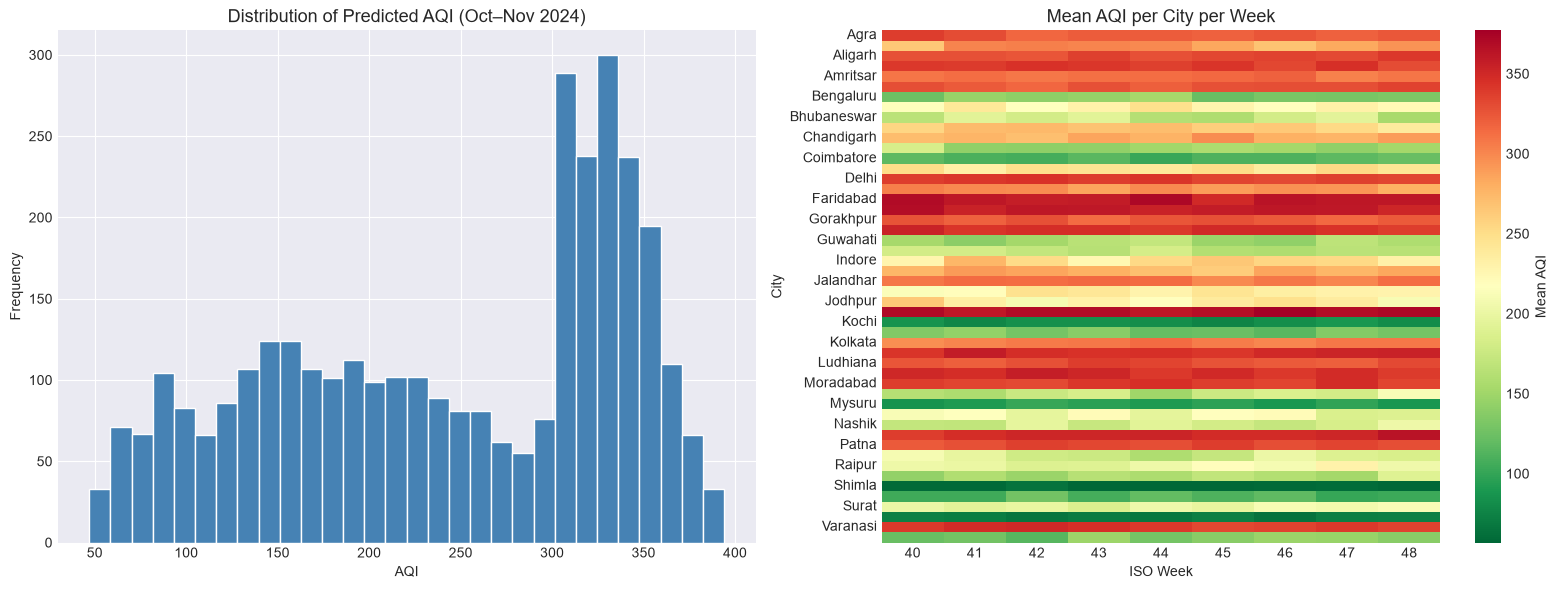

Figure saved.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AQI distribution
aqi_df['aqi_predicted'].hist(bins=30, color='steelblue', edgecolor='white', ax=axes[0])
axes[0].set_title('Distribution of Predicted AQI (Oct–Nov 2024)', fontsize=13)
axes[0].set_xlabel('AQI')
axes[0].set_ylabel('Frequency')

# AQI heatmap — city vs week
aqi_df['week'] = pd.to_datetime(aqi_df['date']).dt.isocalendar().week
pivot = aqi_df.groupby(['city', 'week'])['aqi_predicted'].mean().unstack(fill_value=0)
if pivot.shape[0] > 0:
    sns.heatmap(pivot, cmap='RdYlGn_r', ax=axes[1], cbar_kws={'label': 'Mean AQI'})
    axes[1].set_title('Mean AQI per City per Week', fontsize=13)
    axes[1].set_xlabel('ISO Week')
    axes[1].set_ylabel('City')

plt.tight_layout()
plt.savefig(fig_dir / '01_aqi_distribution.png', dpi=150)
plt.show()
print('Figure saved.')


## 2. HCHO Grid — Spatial Distribution Over India


In [12]:
import os
os.chdir(r'C:\Users\91965\Desktop\vaadrish')
print("Working dir:", os.getcwd())
hcho_files = list(Path('data/raw/gee').glob('hcho_grid_*.csv'))
hcho_df = pd.read_csv(hcho_files[0])
print(f'HCHO grid: {len(hcho_df)} points')
hcho_df.describe()


Working dir: C:\Users\91965\Desktop\vaadrish
HCHO grid: 4969 points


,lon,lat,hcho_value
count,4969.000000,4969.000000,4.969000e+03
mean,82.285530,20.794350,1.281302e-04
std,8.386530,8.740085,5.659891e-05
min,68.000100,6.067866,3.816114e-07
25%,75.052329,13.296474,8.761230e-05
50%,82.070227,20.579823,1.206790e-04
75%,89.535863,28.391532,1.688270e-04
max,96.989120,36.803428,3.686228e-04


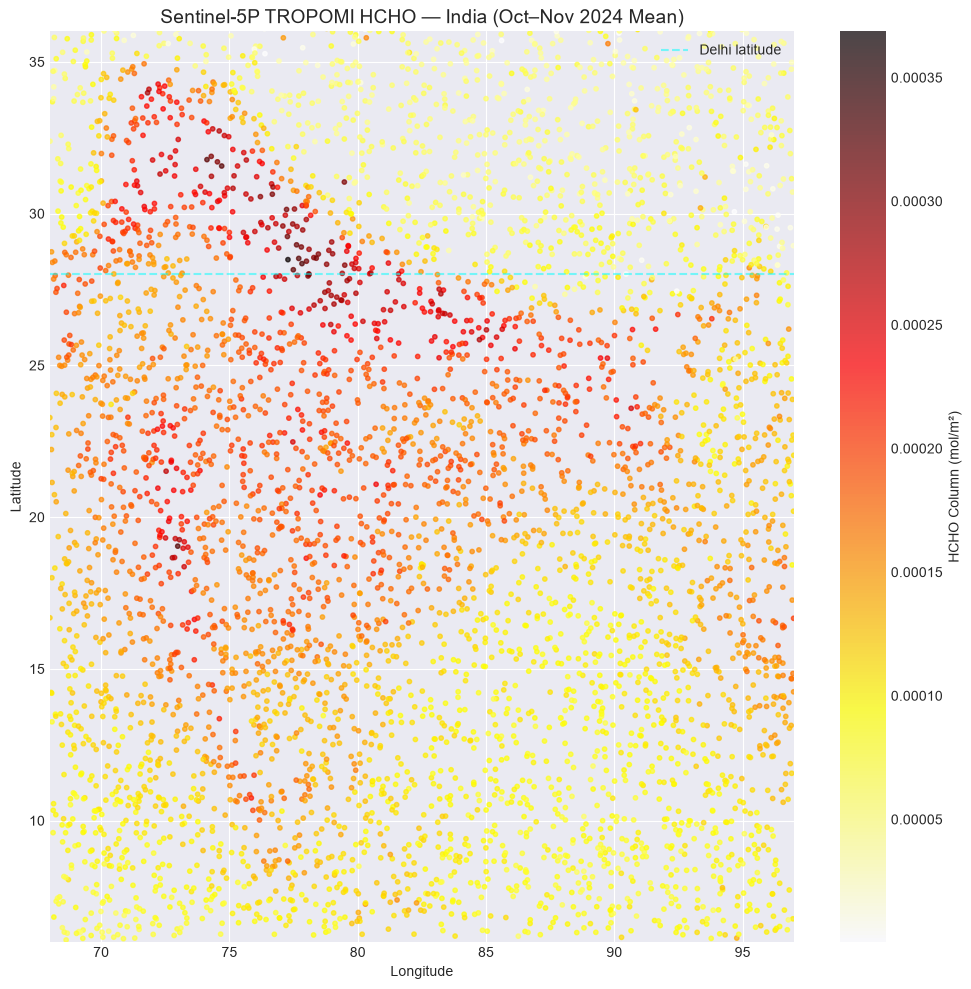

In [17]:
fig, ax = plt.subplots(figsize=(10, 10))
sc = ax.scatter(
    hcho_df['lon'], hcho_df['lat'],
    c=hcho_df['hcho_value'], cmap='hot_r',
    s=10, alpha=0.7
)
plt.colorbar(sc, ax=ax, label='HCHO Column (mol/m²)')
ax.set_xlim(68, 97)
ax.set_ylim(6, 36)
ax.set_title('Sentinel-5P TROPOMI HCHO — India (Oct–Nov 2024 Mean)', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.axhline(y=28, color='cyan', linestyle='--', alpha=0.5, label='Delhi latitude')
ax.legend()
plt.tight_layout()
plt.savefig(fig_dir / '02_hcho_spatial_map.png', dpi=150, bbox_inches='tight')
plt.show()


## 3. Fire Events — Temporal Distribution


In [15]:
fire_df = pd.read_csv('data/raw/fire_india_2024.csv')
fire_df.columns = fire_df.columns.str.lower().str.strip()
fire_df['acq_date'] = pd.to_datetime(fire_df['acq_date'])

# Filter to Oct-Nov 2024
fire_oct_nov = fire_df[
    (fire_df['acq_date'] >= '2024-10-01') & 
    (fire_df['acq_date'] <= '2024-11-30')
]

daily_fires = fire_oct_nov.groupby('acq_date').agg(
    count=('frp', 'count'),
    total_frp=('frp', 'sum')
).reset_index()

print(f'Fire events (Oct-Nov 2024): {len(fire_oct_nov):,}')
print(f'Peak daily fires: {daily_fires["count"].max():,} on {daily_fires.loc[daily_fires["count"].idxmax(), "acq_date"].date()}')


Fire events (Oct-Nov 2024): 67,745
Peak daily fires: 3,325 on 2024-11-18


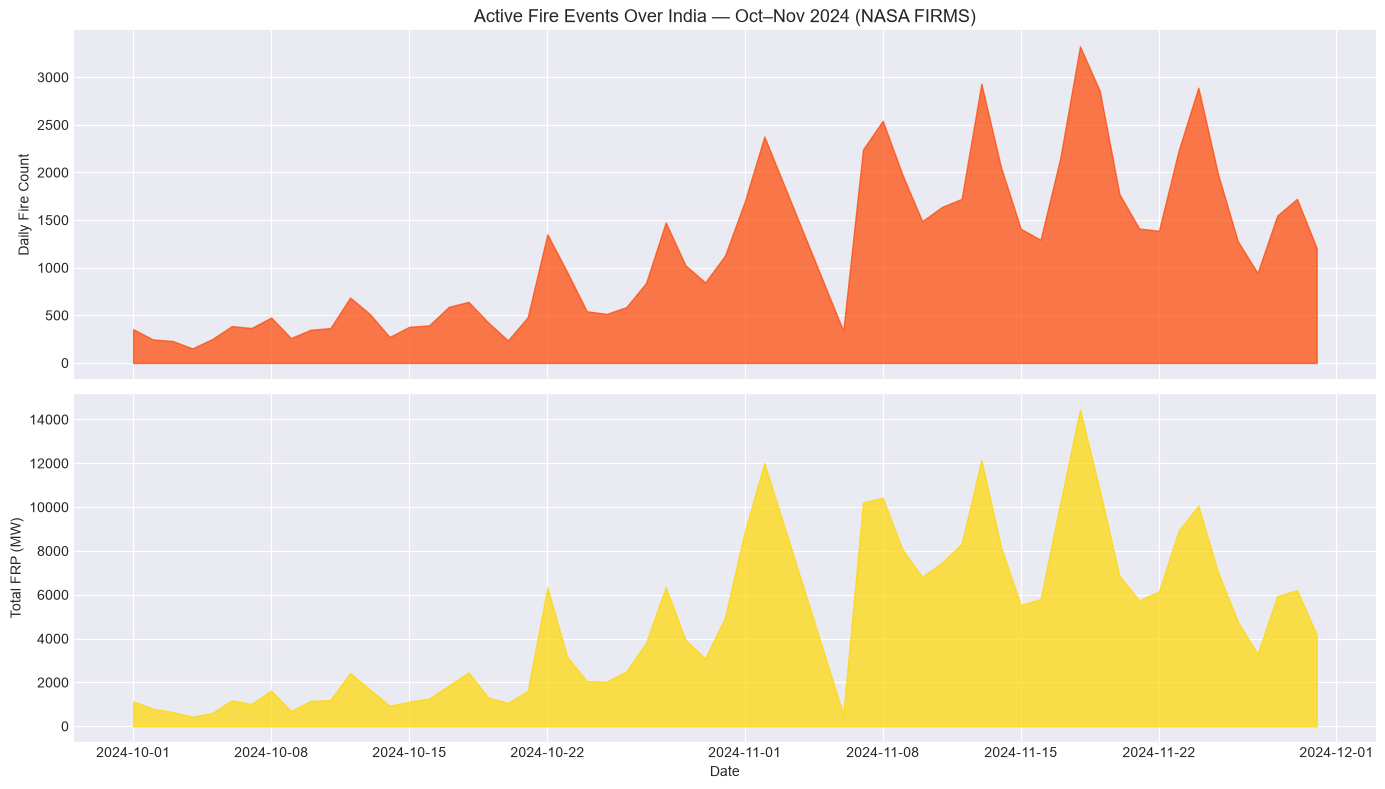

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.fill_between(daily_fires['acq_date'], daily_fires['count'], color='orangered', alpha=0.7)
ax1.set_ylabel('Daily Fire Count')
ax1.set_title('Active Fire Events Over India — Oct–Nov 2024 (NASA FIRMS)', fontsize=13)

ax2.fill_between(daily_fires['acq_date'], daily_fires['total_frp'], color='gold', alpha=0.7)
ax2.set_ylabel('Total FRP (MW)')
ax2.set_xlabel('Date')

plt.tight_layout()
plt.savefig(fig_dir / '03_fire_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Pollutant Correlations (Sentinel-5P)


             lat        lon          no2           so2            co  \
count  20.000000  20.000000    20.000000     20.000000  2.000000e+01   
mean   24.211690  78.651420  4164.264595  10195.062860  1.128550e+06   
std     5.154903   3.703585  1858.585295   8731.620653  1.026801e+05   
min    12.971600  72.571400  1481.962100  -6477.612200  8.578933e+05   
25%    22.215900  77.163400  2815.354250   6085.132525  1.085381e+06   
50%    26.022000  77.524200  3475.526450  10808.261400  1.147761e+06   
75%    28.421550  80.286000  6017.712350  13458.981675  1.197002e+06   
max    30.733300  88.363900  7482.387300  36305.596100  1.270217e+06   

                 o3  
count  2.000000e+01  
mean   5.863397e+06  
std    3.698856e+04  
min    5.812127e+06  
25%    5.841385e+06  
50%    5.852673e+06  
75%    5.888422e+06  
max    5.956770e+06  


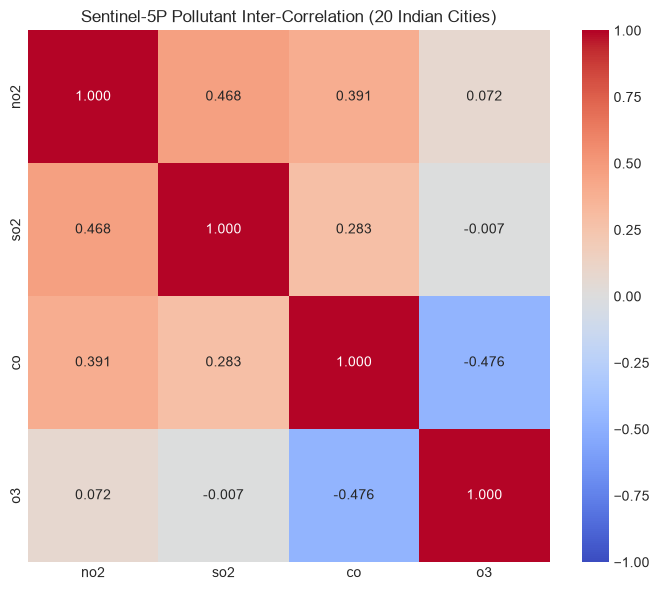

In [19]:
s5p_files = list(Path('data/raw/gee').glob('sentinel5p_*.csv'))
if s5p_files:
    s5p_df = pd.read_csv(s5p_files[0])
    print(s5p_df.describe())
    
    corr = s5p_df[['no2', 'so2', 'co', 'o3']].corr()
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=ax, vmin=-1, vmax=1)
    ax.set_title('Sentinel-5P Pollutant Inter-Correlation (20 Indian Cities)', fontsize=12)
    plt.tight_layout()
    plt.savefig(fig_dir / '04_pollutant_correlation.png', dpi=150)
    plt.show()
else:
    print('Run fetch_multi_pollutant() first.')
